In [21]:
# Load the dataset and basic setup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

titanic_df = pd.read_csv('train.csv')

# Handle missing values
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('S')

# Create family size feature
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


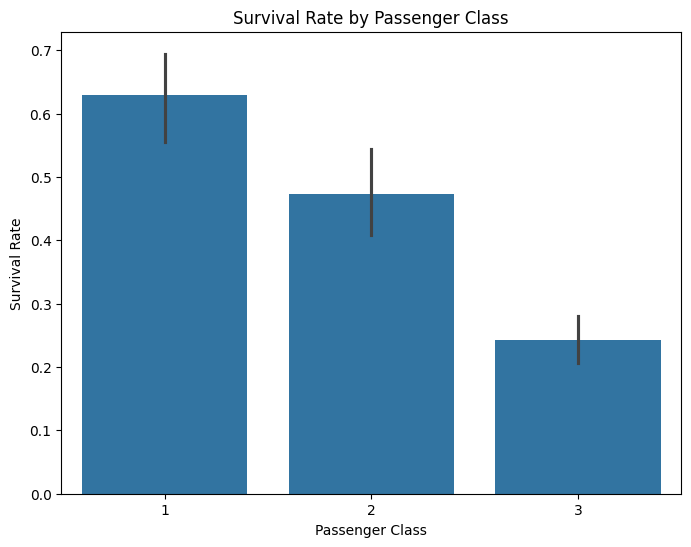

In [22]:
# Task 1: Bar plot - Survival rate by class
plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Survived', data=titanic_df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

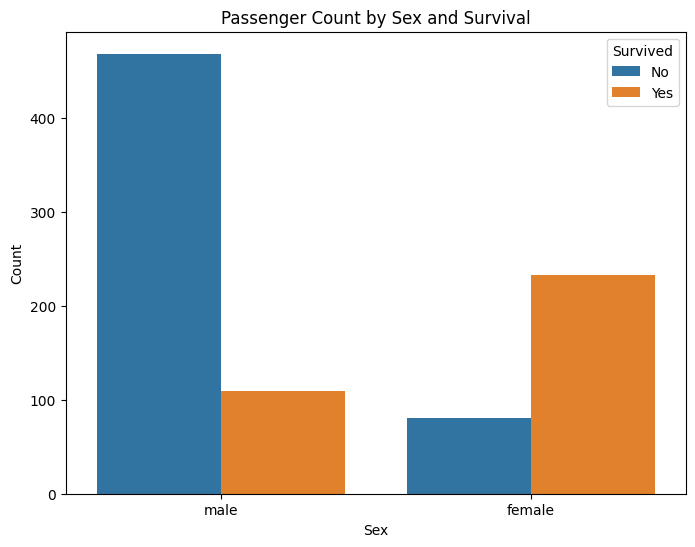

In [23]:
# Task 2: Count plot - Distribution by Sex and Survived
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='Survived', data=titanic_df)
plt.title('Passenger Count by Sex and Survival')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

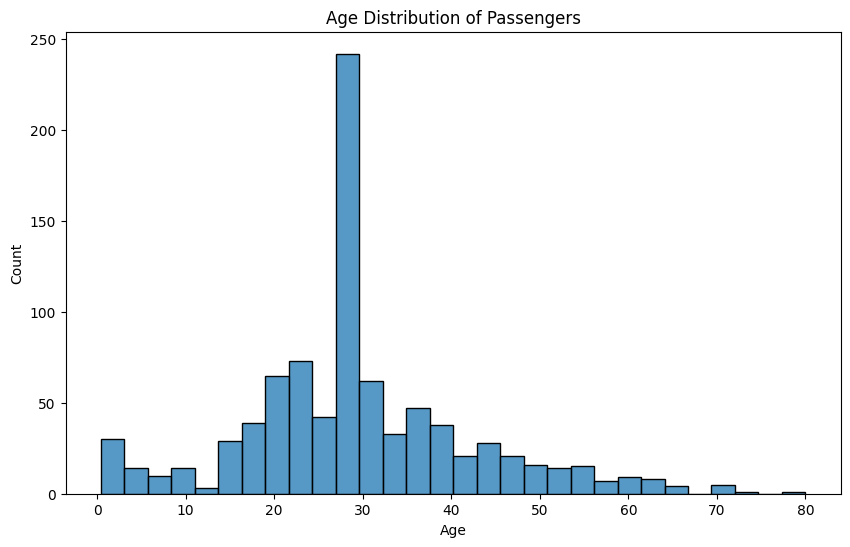

In [24]:
# Task 3: Histogram - Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(x='Age', data=titanic_df, bins=30)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

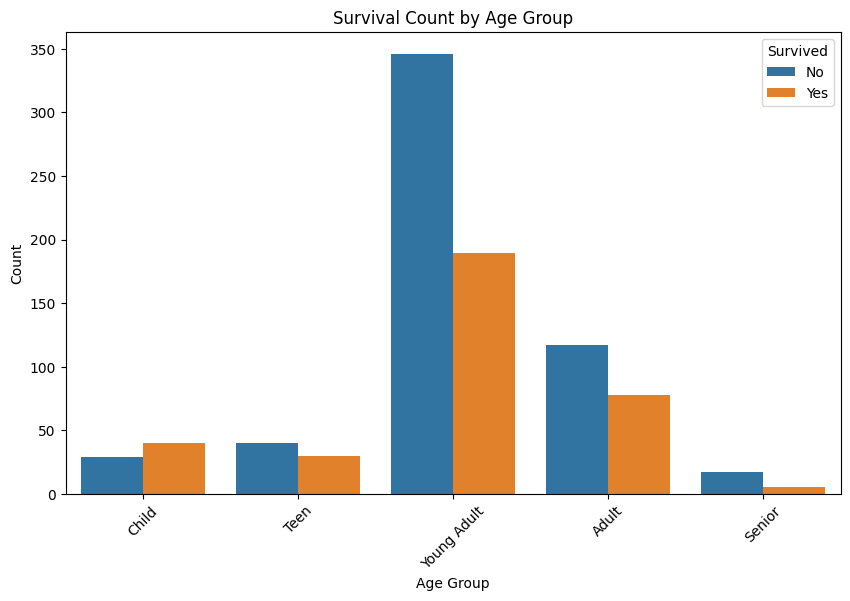

In [25]:
# Task 4: Age groups and survival analysis
# Create age groups
titanic_df['AgeGroup'] = pd.cut(titanic_df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

# Survival by age group
plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', hue='Survived', data=titanic_df)
plt.title('Survival Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.show()

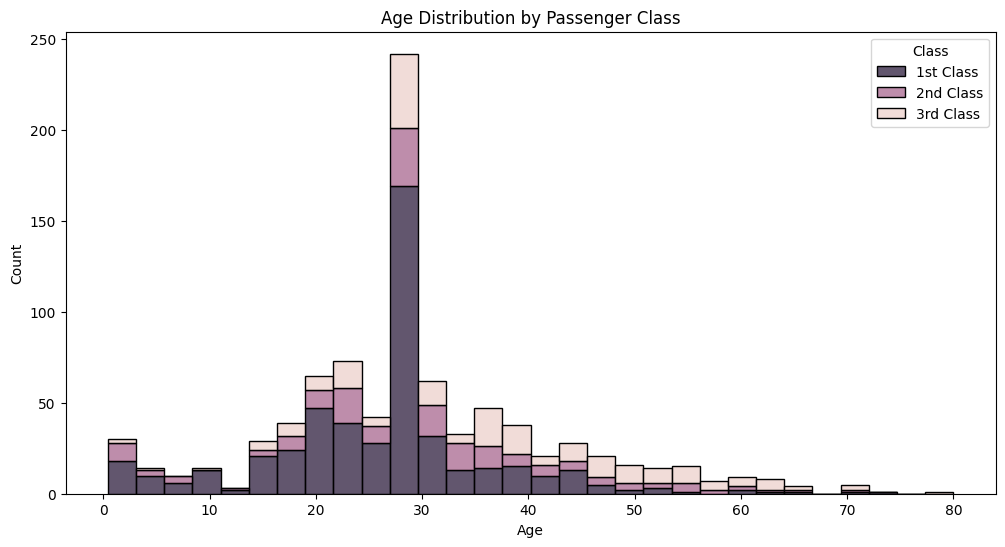

In [26]:
# Age distribution by passenger class
plt.figure(figsize=(12, 6))
sns.histplot(x='Age', hue='Pclass', data=titanic_df, multiple='stack')
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Class', labels=['1st Class', '2nd Class', '3rd Class'])
plt.show()

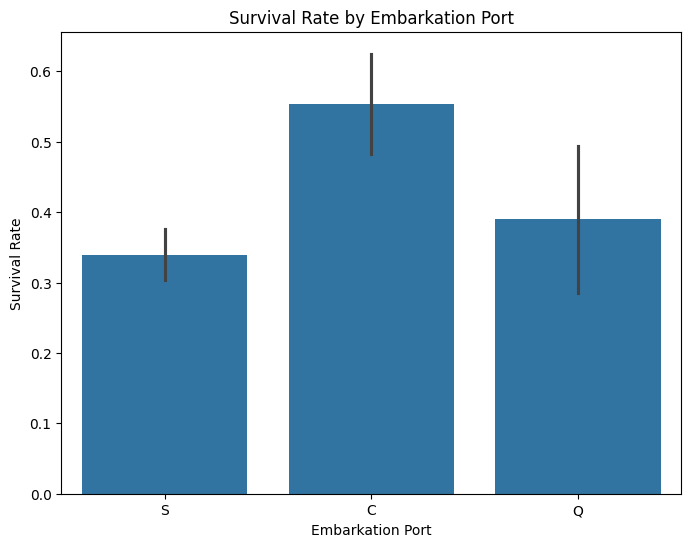

In [27]:
# Additional visualization 1: Survival by Embarked port
plt.figure(figsize=(8, 6))
sns.barplot(x='Embarked', y='Survived', data=titanic_df)
plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Embarkation Port')
plt.ylabel('Survival Rate')
plt.show()

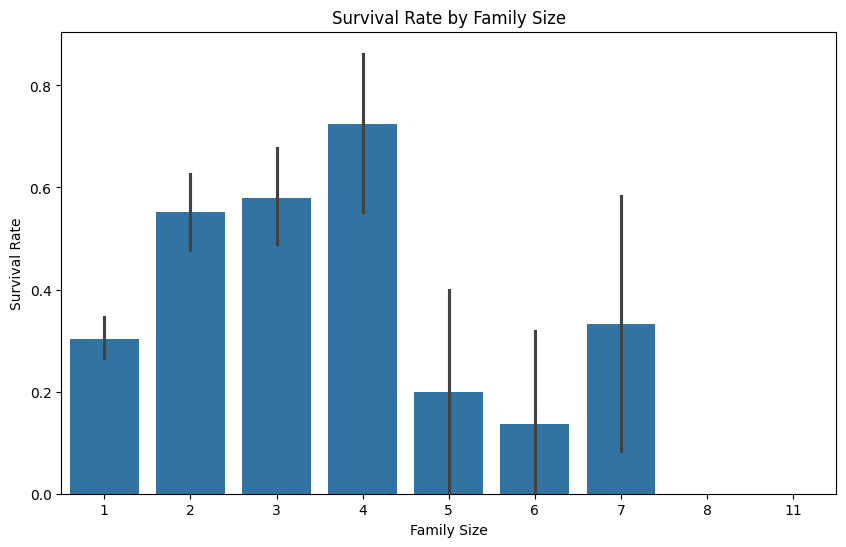

In [28]:
# Additional visualization 2: Family size vs survival
plt.figure(figsize=(10, 6))
sns.barplot(x='FamilySize', y='Survived', data=titanic_df)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

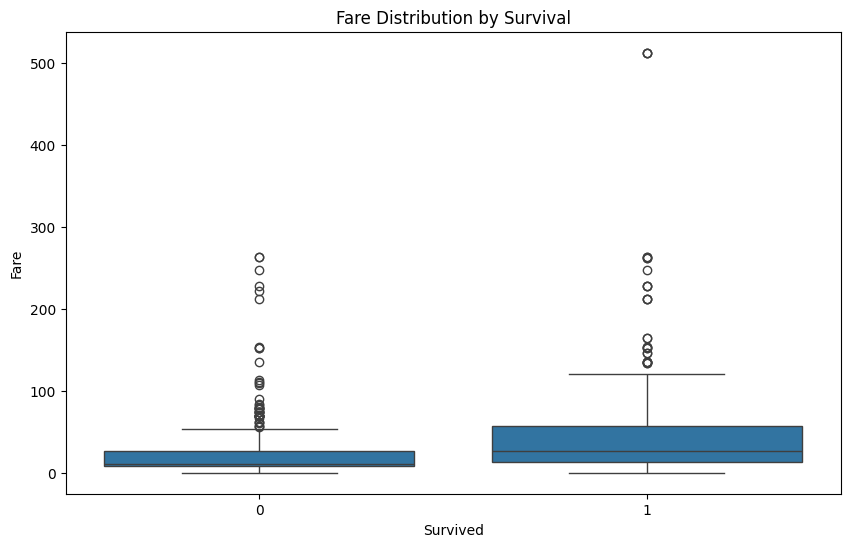

In [29]:
# Additional visualization 3: Fare distribution by survival
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Fare', data=titanic_df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()

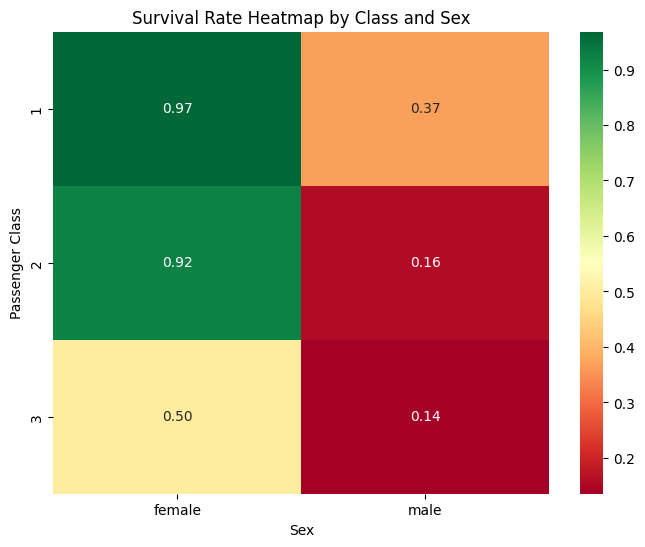

In [30]:
# Additional visualization 4: Heatmap of survival rates
# Create a pivot table for survival rates by class and sex
survival_pivot = titanic_df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(survival_pivot, annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Survival Rate Heatmap by Class and Sex')
plt.xlabel('Sex')
plt.ylabel('Passenger Class')
plt.show()